In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/Users/aarohbale/Desktop/Used-car-price-prediction ML project1/used-car-price-prediction/data/cleaned_cardekho_dataset.csv")

In [3]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


I will now take a look at all the coloumns and assign them to X(features) and Y(labels) accordingly

In [4]:
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='str')

y = Selling price 
X = Remaining columns except car_name because it is only a combination of brand and model so seperate car_name feature is redundant

In [5]:
y = df["selling_price"]
X = df.drop(columns=["car_name","selling_price"])
print(y.head()) #getting confirmation
print("\n")
print(X.head())

0    120000
1    550000
2    215000
3    226000
4    570000
Name: selling_price, dtype: int64


     brand     model  vehicle_age  km_driven seller_type fuel_type  \
0   Maruti      Alto            9     120000  Individual    Petrol   
1  Hyundai     Grand            5      20000  Individual    Petrol   
2  Hyundai       i20           11      60000  Individual    Petrol   
3   Maruti      Alto            9      37000  Individual    Petrol   
4     Ford  Ecosport            6      30000      Dealer    Diesel   

  transmission_type  mileage  engine  max_power  seats  
0            Manual    19.70     796      46.30      5  
1            Manual    18.90    1197      82.00      5  
2            Manual    17.00    1197      80.00      5  
3            Manual    20.92     998      67.10      5  
4            Manual    22.77    1498      98.59      5  


Splitting the data into data for training(80%) and data for testing(20%)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split( X , y , test_size = 0.2 , random_state = 42)

In [8]:
X.info() #now ill take a look and the data types of the columns and then in the next cell divide them based on whether they are categorical or numerical

<class 'pandas.DataFrame'>
RangeIndex: 15244 entries, 0 to 15243
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              15244 non-null  str    
 1   model              15244 non-null  str    
 2   vehicle_age        15244 non-null  int64  
 3   km_driven          15244 non-null  int64  
 4   seller_type        15244 non-null  str    
 5   fuel_type          15244 non-null  str    
 6   transmission_type  15244 non-null  str    
 7   mileage            15244 non-null  float64
 8   engine             15244 non-null  int64  
 9   max_power          15244 non-null  float64
 10  seats              15244 non-null  int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 1.3 MB


In [9]:
categorical_cols = ["brand","model","seller_type","fuel_type","transmission_type"]
numerical_cols = ["vehicle_age","km_driven","mileage","engine","max_power","seats"]

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         categorical_cols),
        ("numerical", StandardScaler(), numerical_cols)
    ]
)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test) #important note: fit should not be used for test set bcuz we will learn from train set and use that on test set , using fit on test set will lead to data leakage

print(X_train_preprocessed.shape)
print(X_test_preprocessed.shape)


(12195, 167)
(3049, 167)


## Model 1: Linear Regression

In [11]:
from sklearn.linear_model import LinearRegression

LinearRegModel = LinearRegression()
LinearRegModel.fit(X_train_preprocessed,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](167,)","[-989510.59,-345376.07,3109606.91,...,-126158.33, 275185.6 , -34485.61]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.293e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,167
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(131)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](167,)","[188.71,130.85,110.98,..., 0. , 0. , 0. ]"


In [12]:
y_test_pred = LinearRegModel.predict(X_test_preprocessed)
print("Prediction values (first 10) ")
print(y_test_pred[:10])
print("Original target values (first 10) ")
print(y_test[:10])

Prediction values (first 10) 
[ 637073.44778503  404027.97544723  697845.21702973 3642073.26457705
  803763.44792483  556138.92664824  164678.54957286 1473265.70893564
  644089.2543417   744307.30552946]
Original target values (first 10) 
4093      680000
10766     350000
10375     675000
3774     7500000
8779      449000
7959      620000
6739      289000
3214      900000
2417      510000
5219      550000
Name: selling_price, dtype: int64


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 169006.86
Root Mean Squared Error (RMSE): 345792.15
R^2 Score: 0.8033


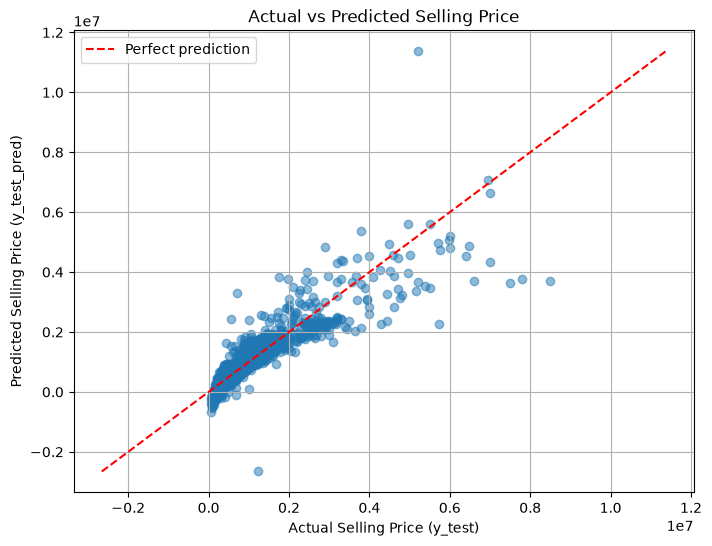

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)

# Perfect prediction reference line
min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], "r--", label="Perfect prediction")

plt.xlabel("Actual Selling Price (y_test)")
plt.ylabel("Predicted Selling Price (y_test_pred)")
plt.title("Actual vs Predicted Selling Price")
plt.legend()
plt.grid(True)
plt.show()

### Linear Regression Conclusion:

Linear Regression achieved an MAE of approximately ₹169,007, RMSE of ₹345,792, and R² of 0.8033.
The model explains about 80.3% of the variation in used-car selling prices and provides a strong baseline for comparison with more advanced models. The higher RMSE compared with MAE suggests that some cars have relatively large prediction errors.

## Model 2: Ridge Regression

The following cells perform 5-fold cross-validation on the training data to select the Ridge regularization strength (alpha) with the lowest mean validation MAE.

In [15]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_sets = []

for fold_number, (train_indices, validation_indices) in enumerate(
    kf.split(X_train), start=1
):
    X_fold_train = X_train.iloc[train_indices]
    X_fold_validation = X_train.iloc[validation_indices]
    y_fold_train = y_train.iloc[train_indices]
    y_fold_validation = y_train.iloc[validation_indices]

    fold_sets.append({
        "fold": fold_number,
        "X_train": X_fold_train,
        "X_validation": X_fold_validation,
        "y_train": y_fold_train,
        "y_validation": y_fold_validation
    })

    print(
        f"Fold {fold_number}: "
        f"{len(X_fold_train)} training samples, "
        f"{len(X_fold_validation)} validation samples"
    )

Fold 1: 9756 training samples, 2439 validation samples
Fold 2: 9756 training samples, 2439 validation samples
Fold 3: 9756 training samples, 2439 validation samples
Fold 4: 9756 training samples, 2439 validation samples
Fold 5: 9756 training samples, 2439 validation samples


In [16]:
from sklearn.base import clone
from sklearn.linear_model import Ridge

alpha_values = [0.01, 0.1, 1, 10, 100]
cv_results = {}

for alpha in alpha_values:
    fold_mae = []

    for fold_data in fold_sets:
        X_fold_train = fold_data["X_train"]
        X_fold_validation = fold_data["X_validation"]
        y_fold_train = fold_data["y_train"]
        y_fold_validation = fold_data["y_validation"]

        # Fit preprocessing only on the current fold's training data
        fold_preprocessor = clone(preprocessor)
        X_fold_train_processed = fold_preprocessor.fit_transform(X_fold_train)
        X_fold_validation_processed = fold_preprocessor.transform(
            X_fold_validation
        )

        # Train and evaluate Ridge regression
        ridge_model = Ridge(alpha=alpha)
        ridge_model.fit(X_fold_train_processed, y_fold_train)

        y_fold_pred = ridge_model.predict(X_fold_validation_processed)
        fold_mae_value = mean_absolute_error(y_fold_validation, y_fold_pred)
        fold_mae.append(fold_mae_value)

        
    mean_mae = np.mean(fold_mae)
    cv_results[alpha] = mean_mae

    print(f"Alpha = {alpha}, Mean MAE: {mean_mae:.2f}")
 


Alpha = 0.01, Mean MAE: 181357.90
Alpha = 0.1, Mean MAE: 181751.60
Alpha = 1, Mean MAE: 189618.11
Alpha = 10, Mean MAE: 211924.27
Alpha = 100, Mean MAE: 225442.89


For alpha = 0.01 , the MAE is the least so I will choose the final value of alpha as 0.01 

In [17]:


RidgeModel = Ridge(alpha=0.01)
RidgeModel.fit(X_train_preprocessed, y_train)
y_test_ridgepred = RidgeModel.predict(X_test_preprocessed)

In [18]:
mae_ridge = mean_absolute_error(y_test, y_test_ridgepred)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_test_ridgepred))
r2_ridge = r2_score(y_test, y_test_ridgepred)

print(f"Ridge MAE: {mae_ridge:.2f}")
print(f"Ridge RMSE: {rmse_ridge:.2f}")
print(f"Ridge R² Score: {r2_ridge:.4f}")

Ridge MAE: 169025.50
Ridge RMSE: 345744.99
Ridge R² Score: 0.8034


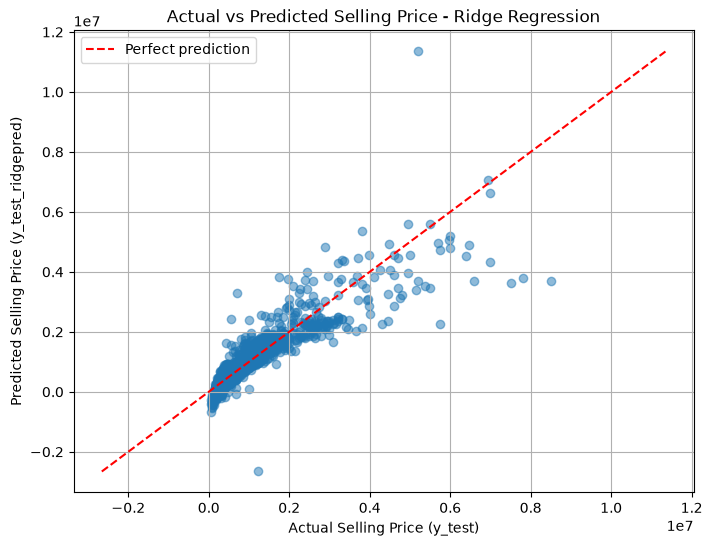

In [19]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_test_ridgepred, alpha=0.5)

min_value = min(y_test.min(), y_test_ridgepred.min())
max_value = max(y_test.max(), y_test_ridgepred.max())
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "r--",
    label="Perfect prediction"
)

plt.xlabel("Actual Selling Price (y_test)")
plt.ylabel("Predicted Selling Price (y_test_ridgepred)")
plt.title("Actual vs Predicted Selling Price - Ridge Regression")
plt.legend()
plt.grid(True)
plt.show()

### Ridge Regression Conclusion:

The tuned Ridge Regression model (alpha = 0.01) achieved performance very similar to the Linear Regression baseline.
Linear Regression: MAE ≈ ₹,169,007, RMSE ≈ ₹3,45,792, R² ≈ 0.8033
Ridge Regression: MAE ≈ ₹1,69,026, RMSE ≈ ₹3,45,745, R² ≈ 0.8034

Ridge slightly improved RMSE and R², while Linear Regression had a slightly lower MAE. Overall, the differences are negligible, suggesting that L2 regularization did not significantly improve performance on this dataset.

## Model 3: Decision Tree Regresson

In [20]:
from sklearn.tree import DecisionTreeRegressor

DT1 = DecisionTreeRegressor(random_state=42) # random state will make sure that the same tree is reproduced everytime
DT1.fit(X_train_preprocessed, y_train)

y_test_DT1pred = DT1.predict(X_test_preprocessed)

In [21]:
#Evaluation of the decision tree regressor model
mae_DT1 = mean_absolute_error(y_test, y_test_DT1pred)
rmse_DT1 = np.sqrt(mean_squared_error(y_test, y_test_DT1pred))
r2_DT1 = r2_score(y_test, y_test_DT1pred)

print(f"Decision Tree MAE: {mae_DT1:.2f}")
print(f"Decision Tree RMSE: {rmse_DT1:.2f}")
print(f"Decision Tree R² Score: {r2_DT1:.4f}")

Decision Tree MAE: 128271.52
Decision Tree RMSE: 336715.01
Decision Tree R² Score: 0.8135


In [22]:
#Checking if the model is overfitting by comparing training vs testing errors
y_train_DT1pred = DT1.predict(X_train_preprocessed)

mae_DT1_train = mean_absolute_error(y_train, y_train_DT1pred)
rmse_DT1_train = np.sqrt(mean_squared_error(y_train, y_train_DT1pred))
r2_DT1_train = r2_score(y_train, y_train_DT1pred)

print(f"Decision Tree MAE: {mae_DT1_train:.2f}")
print(f"Decision Tree RMSE: {rmse_DT1_train:.2f}")
print(f"Decision Tree R² Score: {r2_DT1_train:.4f}")

Decision Tree MAE: 4799.00
Decision Tree RMSE: 19681.92
Decision Tree R² Score: 0.9995


The error on test set appears to be much higher than the error on training set which clearly indicates overfitting

Now I will tune the decision tree regressor model with the help of some hyperparameters and see if it helps in reducing overfitting and making the predictions more accurate

In [23]:
#hyperparameters

# splitting is allowed till these are not violated
max_depth = [5,10, 12, 15, 20, 25, 30, 35]  # Maxium depth that the tree can reach
min_samples_to_split = [2, 5, 10, 12, 15, 20, 25, 30, 35, 40]   # Minimum number of samples that a node must have in order for it further split  
min_samples_in_child_nodes = [1, 2, 3, 4] # Minimum number of samples that must be present in each of the child nodes after splitting

# Total combinations of all 3 hyperparameters to try from = 8 x 8 x 4 = 256


 Try all 256 hyperparameter combinations using 5-fold cross-validation.
 Each combination is trained and validated on 5 folds (256 x 5 = 1280 total fits).
 Select the combination with the lowest mean CV MAE.

In [24]:

all_dt_results = []
best_params = None
best_mae = float("inf")

for depth in max_depth:
    for min_split in min_samples_to_split:
        for min_leaf in min_samples_in_child_nodes:
            fold_mae = []

            for fold_data in fold_sets:
                X_fold_train = fold_data["X_train"]
                X_fold_validation = fold_data["X_validation"]
                y_fold_train = fold_data["y_train"]
                y_fold_validation = fold_data["y_validation"]

                # Fit preprocessing only on the current fold's training data
                fold_preprocessor = clone(preprocessor)
                X_train_fold_processed = fold_preprocessor.fit_transform(
                    X_fold_train
                )
                X_validation_fold_processed = fold_preprocessor.transform(
                    X_fold_validation
                )

                model = DecisionTreeRegressor(
                    max_depth=depth,
                    min_samples_split=min_split,
                    min_samples_leaf=min_leaf,
                    random_state=42
                )

                model.fit(X_train_fold_processed, y_fold_train)
                predictions = model.predict(X_validation_fold_processed)

                fold_mae.append(
                    mean_absolute_error(y_fold_validation, predictions)
                )

            mean_cv_mae = np.mean(fold_mae)

            result = {
                "max_depth": depth,
                "min_samples_split": min_split,
                "min_samples_leaf": min_leaf,
                "mean_mae": mean_cv_mae
            }
            all_dt_results.append(result)

            if mean_cv_mae < best_mae:
                best_mae = mean_cv_mae
                best_params = {
                    "max_depth": depth,
                    "min_samples_split": min_split,
                    "min_samples_leaf": min_leaf
                }

print("Best parameters:", best_params)
print(f"Lowest mean CV MAE: {best_mae:.2f}")

Best parameters: {'max_depth': 12, 'min_samples_split': 2, 'min_samples_leaf': 1}
Lowest mean CV MAE: 118443.63


After tuning the model , it turns out that max_depth : 12, min_samples_split: 2, min_samples_leaf: 1 are the best possible values for the hyperparameters 

In [25]:
# Training the model with hyperparams on the training set

DT1tuned = DecisionTreeRegressor(max_depth=12 ,min_samples_split= 2, min_samples_leaf=1, random_state=42)
DT1tuned.fit(X_train_preprocessed,y_train)
DT1tuned_pred = DT1tuned.predict(X_test_preprocessed) 


In [26]:
#Evaluating the tuned Decision Tree on test set

mae_DT1tuned = mean_absolute_error(y_test, DT1tuned_pred)
rmse_DT1tuned = np.sqrt(mean_squared_error(y_test, DT1tuned_pred))
r2_DT1tuned = r2_score(y_test, DT1tuned_pred)

print(f"Tuned Decision Tree MAE: {mae_DT1tuned:.2f}")
print(f"Tuned Decision Tree RMSE: {rmse_DT1tuned:.2f}")
print(f"Tuned Decision Tree R² Score: {r2_DT1tuned:.4f}")

Tuned Decision Tree MAE: 115542.46
Tuned Decision Tree RMSE: 308722.99
Tuned Decision Tree R² Score: 0.8432


In [28]:
#Evalutaing the tuned Decision Tree on training data to see how tuning has affected overfitting

y_train_DT1tuned_pred = DT1tuned.predict(X_train_preprocessed)

mae_DT1_train = mean_absolute_error(y_train, y_train_DT1tuned_pred )
rmse_DT1_train = np.sqrt(mean_squared_error(y_train, y_train_DT1tuned_pred ))
r2_DT1_train = r2_score(y_train, y_train_DT1tuned_pred )

print(f"Decision Tree MAE: {mae_DT1_train:.2f}")
print(f"Decision Tree RMSE: {rmse_DT1_train:.2f}")
print(f"Decision Tree R² Score: {r2_DT1_train:.4f}")

Decision Tree MAE: 68231.24
Decision Tree RMSE: 118689.05
Decision Tree R² Score: 0.9834


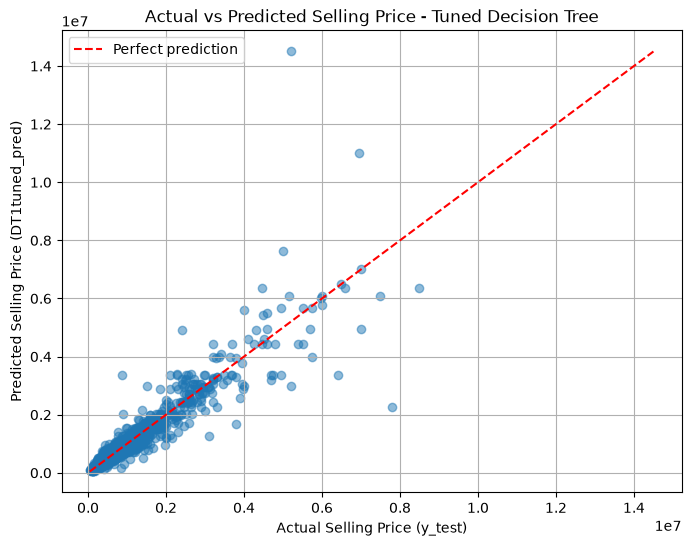

In [47]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, DT1tuned_pred, alpha=0.5)

min_value = min(y_test.min(), DT1tuned_pred.min())
max_value = max(y_test.max(), DT1tuned_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "r--",
    label="Perfect prediction"
)

plt.xlabel("Actual Selling Price (y_test)")
plt.ylabel("Predicted Selling Price (DT1tuned_pred)")
plt.title("Actual vs Predicted Selling Price - Tuned Decision Tree")
plt.legend()
plt.grid(True)
plt.show()

### Decision Tree Regression Conclusion

The initial Decision Tree heavily overfit the training data, achieving a training R² of 0.9995 but a test R² of only 0.8135.

After tuning the tree using 5-fold cross-validation, the selected hyperparameters were `max_depth=12`, `min_samples_split=2`, and `min_samples_leaf=1`.

The tuned model achieved:
- MAE: ₹1,15,542
- RMSE: ₹3,08,722
- R²: 0.8432

Although some overfitting still remains, restricting the tree significantly improved its generalization and test performance. The tuned Decision Tree also outperformed both Linear Regression and Ridge Regression.

## Model 4: Random Forest Regression

In [32]:
from sklearn.ensemble import RandomForestRegressor

RFRmodel = RandomForestRegressor(n_estimators=100 , random_state=42 , n_jobs=-1)
RFRmodel.fit(X_train_preprocessed,y_train)

RFRmodel_pred = RFRmodel.predict(X_test_preprocessed)


In [33]:
# Model evalutaion on Testing set
mae_rfr = mean_absolute_error(y_test, RFRmodel_pred)
rmse_rfr = np.sqrt(mean_squared_error(y_test, RFRmodel_pred))
r2_rfr = r2_score(y_test, RFRmodel_pred)

print(f"Random Forest MAE: {mae_rfr:.2f}")
print(f"Random Forest RMSE: {rmse_rfr:.2f}")
print(f"Random Forest R² Score: {r2_rfr:.4f}")

Random Forest MAE: 100156.52
Random Forest RMSE: 269199.57
Random Forest R² Score: 0.8808


In [35]:
# Model evalutaion on Training set

RFRmodel_pred_on_trainset = RFRmodel.predict(X_train_preprocessed)


mae_rfr_trainset  = mean_absolute_error(y_train, RFRmodel_pred_on_trainset)
rmse_rfr_trainset  = np.sqrt(mean_squared_error(y_train, RFRmodel_pred_on_trainset))
r2_rfr_trainset  = r2_score(y_train, RFRmodel_pred_on_trainset)

print(f"Random Forest MAE: {mae_rfr_trainset :.2f}")
print(f"Random Forest RMSE: {rmse_rfr_trainset :.2f}")
print(f"Random Forest R² Score: {r2_rfr_trainset :.4f}")

Random Forest MAE: 39123.71
Random Forest RMSE: 129128.97
Random Forest R² Score: 0.9803


The errors on training set appear to be substantially lower than the errors on the testing set indicating that there is overfitting in this model. This has to be dealt with the help of hyperparameters tuning which i will do in the following cells 

In [36]:
# Hyperparameters 

number_of_trees = [64, 100 , 200 , 300 ,  500] # Number of trees present in the ensemble
maximum_depth = [5,10,15,25,30,50,None] # Maxium depth that the tree can reach.
min_samples_to_splitfrom = [2,5,10,20]  # Minimum number of samples that a node must have in order for it further split
min_samples_in_childnodes = [1,2,5,10]  # Minimum number of samples that must be present in each of the child nodes after splitting
maxfeatures = ["sqrt" , 0.3 ,0.5 , 0.7 , 1.0] # Number of features considered at each split when searching for the best split

# Total combinations = 5 x 7 x 4 x 4 x 5 = 2800


Random Forest Hyperparameter Tuning — Randomized Search with 5-Fold Cross-Validation

Generate all 2,800 possible hyperparameter combinations and randomly select 50 unique combinations for evaluation.

Each selected combination is evaluated using 5-fold cross-validation (50 × 5 = 250 total Random Forest fits). Preprocessing is fitted separately on the training portion of each fold to prevent data leakage.

For every combination, calculate the mean validation MAE across the 5 folds. The hyperparameter combination with the lowest mean CV MAE is selected for further refinement.

In [40]:
import itertools

# Generate all 2800 hyperparameter combinations
ALLcombinations = list(itertools.product(
    number_of_trees,
    maximum_depth,
    min_samples_to_splitfrom,
    min_samples_in_childnodes,
    maxfeatures
))

# Randomly select 50 unique combinations
import random

random.seed(42)

combinationSubset = random.sample(
    ALLcombinations,
    50
)

rf_cv_results = []
best_rf_mean_mae = float("inf")
best_rf_params = None

for combination_number, combination in enumerate(combinationSubset, start=1):
    (
        n_trees,
        max_depth_value,
        min_split_value,
        min_leaf_value,
        max_features_value
    ) = combination

    fold_mae = []

    for fold_data in fold_sets:
        X_fold_train = fold_data["X_train"]
        X_fold_validation = fold_data["X_validation"]
        y_fold_train = fold_data["y_train"]
        y_fold_validation = fold_data["y_validation"]

        # Fit preprocessing only on the training portion of each fold
        fold_preprocessor = clone(preprocessor)
        X_fold_train_processed = fold_preprocessor.fit_transform(X_fold_train)
        X_fold_validation_processed = fold_preprocessor.transform(
            X_fold_validation
        )

        rf_model = RandomForestRegressor(
            n_estimators=n_trees,
            max_depth=max_depth_value,
            min_samples_split=min_split_value,
            min_samples_leaf=min_leaf_value,
            max_features=max_features_value,
            random_state=42,
            n_jobs=-1
        )

        rf_model.fit(X_fold_train_processed, y_fold_train)
        fold_predictions = rf_model.predict(X_fold_validation_processed)

        fold_mae.append(
            mean_absolute_error(y_fold_validation, fold_predictions)
        )

    mean_rf_mae = np.mean(fold_mae)

    result = {
        "n_estimators": n_trees,
        "max_depth": max_depth_value,
        "min_samples_split": min_split_value,
        "min_samples_leaf": min_leaf_value,
        "max_features": max_features_value,
        "mean_cv_mae": mean_rf_mae
    }

    rf_cv_results.append(result)

    if mean_rf_mae < best_rf_mean_mae:
        best_rf_mean_mae = mean_rf_mae
        best_rf_params = result.copy()


print("\nBest Random Forest hyperparameters:")
print(best_rf_params)
print(f"Lowest mean CV MAE: {best_rf_mean_mae:.2f}")


Best Random Forest hyperparameters:
{'n_estimators': 100, 'max_depth': 30, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'mean_cv_mae': np.float64(99597.20399607334)}
Lowest mean CV MAE: 99597.20


Refined Random Forest Hyperparameters

Define a smaller hyperparameter grid around the best values found during randomized search. These combinations will be evaluated using 5-fold cross-validation to find the final Random Forest configuration.

In [42]:
# Refined Hyperparameters 

number_of_trees_fine = [100] # Number of trees present in the ensemble
maximum_depth_fine = [20,25,30,35,40] # Maxium depth that the tree can reach.
min_samples_to_splitfrom_fine = [2,3,5,7,10]  # Minimum number of samples that a node must have in order for it further split
min_samples_in_childnodes_fine = [1]  # Minimum number of samples that must be present in each of the child nodes after splitting
maxfeatures_fine = [0.4 ,0.5 , 0.6] # Number of features considered at each split when searching for the best split

# Total combinations = 75

Random Forest Fine-Tuning — Grid Search with 5-Fold Cross-Validation

Based on the best hyperparameters found during the randomized search, test 75 nearby hyperparameter combinations to further refine the Random Forest model.

Each combination is evaluated using 5-fold cross-validation (75 × 5 = 375 total Random Forest fits). Preprocessing is fitted separately on the training portion of each fold to prevent data leakage.

For every combination, calculate the mean validation MAE across the 5 folds. The hyperparameter combination with the lowest mean CV MAE is selected as the final Random Forest configuration.

In [43]:
# Fine-tune the Random Forest model using all 75 combinations
fine_rf_results = []
best_fine_rf_params = None
best_fine_rf_mae = float("inf")

for n_trees in number_of_trees_fine:
    for max_depth_value in maximum_depth_fine:
        for min_split_value in min_samples_to_splitfrom_fine:
            for min_leaf_value in min_samples_in_childnodes_fine:
                for max_features_value in maxfeatures_fine:

                    fold_mae = []

                    for fold_data in fold_sets:
                        X_fold_train = fold_data["X_train"]
                        X_fold_validation = fold_data["X_validation"]
                        y_fold_train = fold_data["y_train"]
                        y_fold_validation = fold_data["y_validation"]

                        # Fit preprocessing only on the fold's training data
                        fold_preprocessor = clone(preprocessor)
                        X_fold_train_processed = fold_preprocessor.fit_transform(
                            X_fold_train
                        )
                        X_fold_validation_processed = fold_preprocessor.transform(
                            X_fold_validation
                        )

                        fine_rf_model = RandomForestRegressor(
                            n_estimators=n_trees,
                            max_depth=max_depth_value,
                            min_samples_split=min_split_value,
                            min_samples_leaf=min_leaf_value,
                            max_features=max_features_value,
                            random_state=42,
                            n_jobs=-1
                        )

                        fine_rf_model.fit(
                            X_fold_train_processed,
                            y_fold_train
                        )

                        fold_predictions = fine_rf_model.predict(
                            X_fold_validation_processed
                        )

                        fold_mae.append(
                            mean_absolute_error(
                                y_fold_validation,
                                fold_predictions
                            )
                        )

                    mean_fine_mae = np.mean(fold_mae)

                    result = {
                        "n_estimators": n_trees,
                        "max_depth": max_depth_value,
                        "min_samples_split": min_split_value,
                        "min_samples_leaf": min_leaf_value,
                        "max_features": max_features_value,
                        "mean_cv_mae": mean_fine_mae
                    }

                    fine_rf_results.append(result)

                    if mean_fine_mae < best_fine_rf_mae:
                        best_fine_rf_mae = mean_fine_mae
                        best_fine_rf_params = result.copy()

print("Best fine-tuned parameters:")
print(best_fine_rf_params)
print(f"Lowest mean CV MAE: {best_fine_rf_mae:.2f}")

Best fine-tuned parameters:
{'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 0.4, 'mean_cv_mae': np.float64(99145.89475230503)}
Lowest mean CV MAE: 99145.89


Final hyperparameters to tune the model :  
n_estimators      = 100,
max_depth         = 20,
min_samples_split = 3,
min_samples_leaf  = 1,
max_features      = 0.4


In [45]:
#Train and predict with the tuned model
RFRmodel_tuned = RandomForestRegressor(n_estimators=100 , max_depth=20,min_samples_split=3 ,min_samples_leaf=1, max_features=0.4, random_state=42 , n_jobs=-1)
RFRmodel_tuned.fit(X_train_preprocessed,y_train)

RFRmodel_tuned_pred = RFRmodel_tuned.predict(X_test_preprocessed)

In [46]:
# Evaluate the tuned Random Forest model on the test set

mae_rfr_tuned = mean_absolute_error(y_test, RFRmodel_tuned_pred)
rmse_rfr_tuned = np.sqrt(mean_squared_error(y_test, RFRmodel_tuned_pred))
r2_rfr_tuned = r2_score(y_test, RFRmodel_tuned_pred)

print(f"Tuned Random Forest MAE: {mae_rfr_tuned:.2f}")
print(f"Tuned Random Forest RMSE: {rmse_rfr_tuned:.2f}")
print(f"Tuned Random Forest R² Score: {r2_rfr_tuned:.4f}")

Tuned Random Forest MAE: 97696.23
Tuned Random Forest RMSE: 241634.88
Tuned Random Forest R² Score: 0.9040


In [48]:

#Evaluate the tuned model on the training set and compare its performance with the test set to check whether significant overfitting is still present.

RFRmodel_tuned_pred_on_trainset = RFRmodel_tuned.predict(X_train_preprocessed)

mae_rfr_tuned_train = mean_absolute_error(
    y_train, RFRmodel_tuned_pred_on_trainset
)
rmse_rfr_tuned_train = np.sqrt(
    mean_squared_error(y_train, RFRmodel_tuned_pred_on_trainset)
)
r2_rfr_tuned_train = r2_score(
    y_train, RFRmodel_tuned_pred_on_trainset
)

print(f"Tuned Random Forest Training MAE: {mae_rfr_tuned_train:.2f}")
print(f"Tuned Random Forest Training RMSE: {rmse_rfr_tuned_train:.2f}")
print(f"Tuned Random Forest Training R² Score: {r2_rfr_tuned_train:.4f}")

Tuned Random Forest Training MAE: 50041.39
Tuned Random Forest Training RMSE: 143626.81
Tuned Random Forest Training R² Score: 0.9757


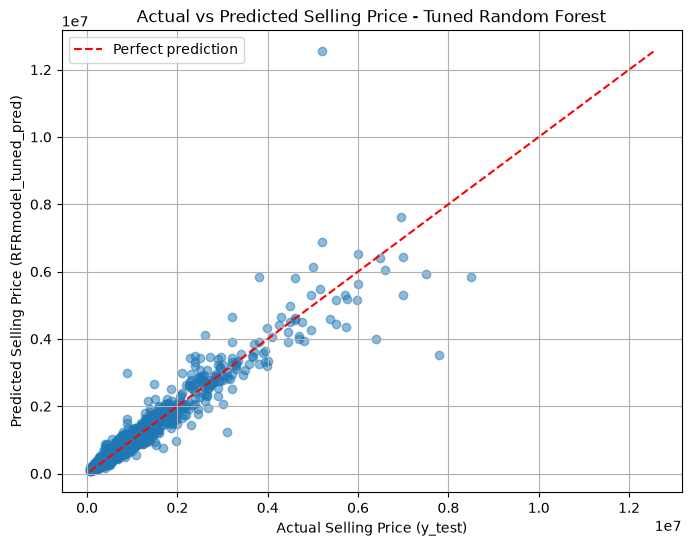

In [49]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, RFRmodel_tuned_pred, alpha=0.5)

min_value = min(y_test.min(), RFRmodel_tuned_pred.min())
max_value = max(y_test.max(), RFRmodel_tuned_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    "r--",
    label="Perfect prediction"
)

plt.xlabel("Actual Selling Price (y_test)")
plt.ylabel("Predicted Selling Price (RFRmodel_tuned_pred)")
plt.title("Actual vs Predicted Selling Price - Tuned Random Forest")
plt.legend()
plt.grid(True)
plt.show()

### Random Forest Regression Conclusion

The baseline Random Forest already performed better than the previous Linear, Ridge, and Decision Tree models. Hyperparameter tuning was performed using a randomized search followed by a refined grid search with 5-fold cross-validation.

The final Random Forest used:
- `n_estimators = 100`
- `max_depth = 20`
- `min_samples_split = 3`
- `min_samples_leaf = 1`
- `max_features = 0.4`

The tuned model achieved a test MAE of approximately ₹97,696, RMSE of ₹241,635, and R² of 0.9040. Although some train-test performance gap remains, the tuned model generalizes substantially better than the single Decision Tree and provides the strongest test performance among the models evaluated so far.